## Boxplot y gráficas de tendencia


Could not determine dtype for column 1, falling back to string



📊 Analizando hoja: IED Interior


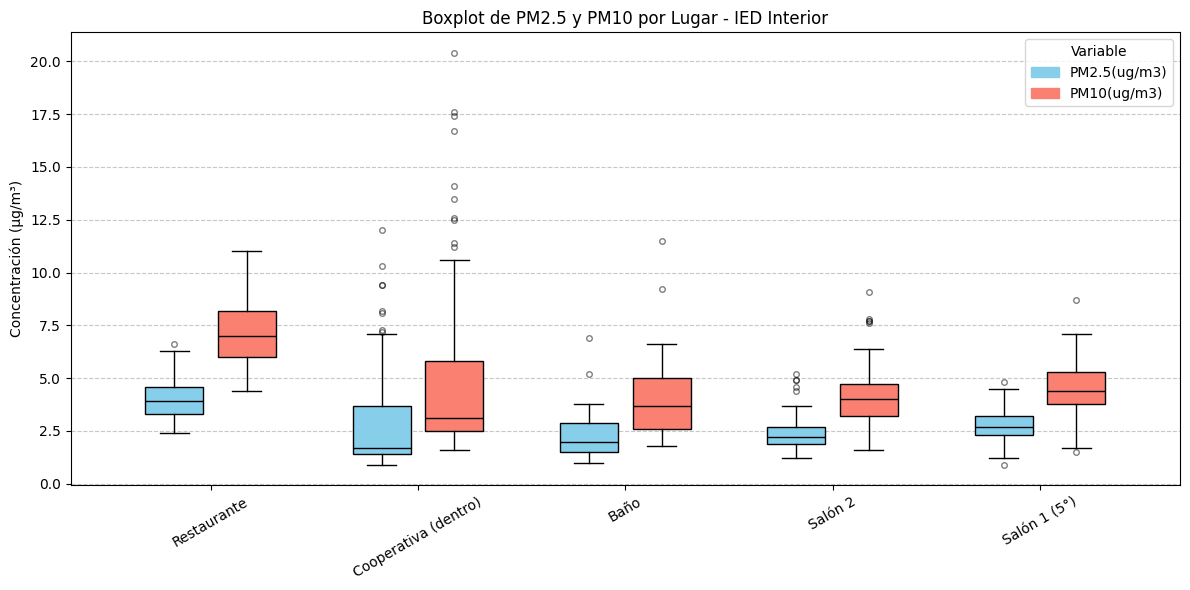

Could not determine dtype for column 1, falling back to string



📊 Analizando hoja: Santa Juanita Interior


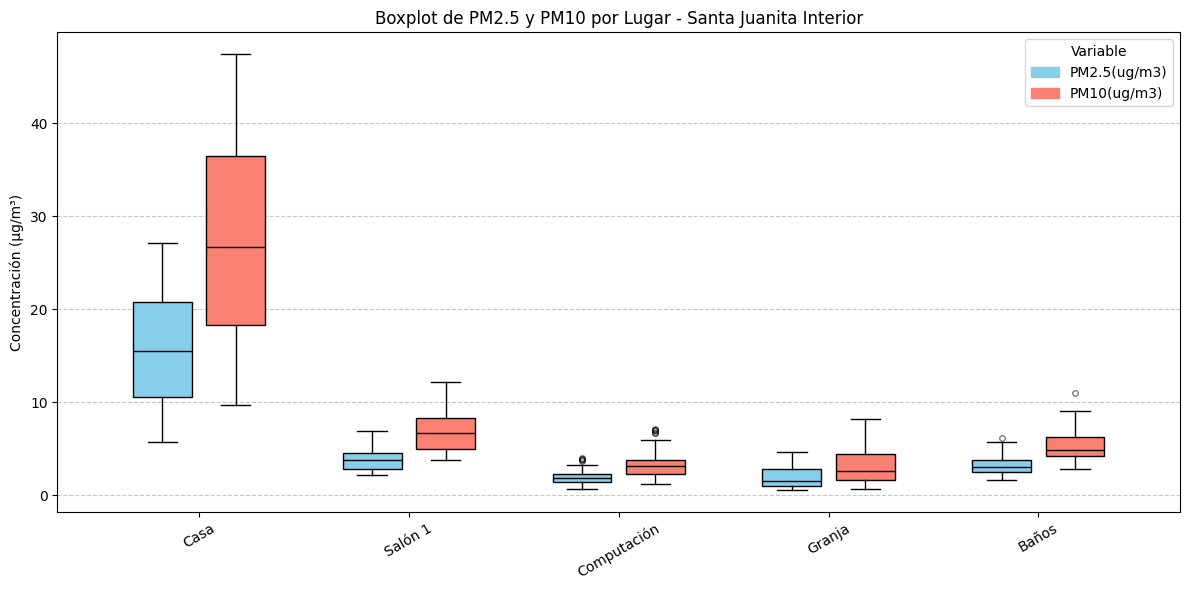

In [8]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# ================
# CONFIGURACIÓN
# ================
file_path = "Datos Unificados.ods"

# Hojas de tu archivo (ajusta según corresponda)
sheets = ["IED Interior", "Santa Juanita Interior"]

# Variables a analizar
variables = ["PM2.5(ug/m3)", "PM10(ug/m3)"]
colores = ["skyblue", "salmon"]  # Colores para cada variable


# ================
# FUNCIÓN DE ANÁLISIS
# ================
def analisis_exploratorio(sheet_name):
    print(f"\n📊 Analizando hoja: {sheet_name}")

    # 1. Cargar datos
    df = pl.read_excel(file_path, sheet_name=sheet_name)

    # 2. Verificar columnas necesarias
    if "Lugar" not in df.columns:
        print(f"⚠️ No existe columna 'Lugar' en {sheet_name}")
        return

    for var in variables:
        if var not in df.columns:
            print(f"⚠️ La variable {var} no está en {sheet_name}")
            return

    # 3. Preparar datos por lugar
    lugares = df["Lugar"].unique().to_list()
    posiciones = np.arange(len(lugares))  # posiciones base en el eje X
    ancho = 0.35  # separación entre PM2.5 y PM10

    # Crear gráfico
    plt.figure(figsize=(12, 6))

    for i, var in enumerate(variables):
        datos = [df.filter(df["Lugar"] == lugar)[var].drop_nulls().to_list() for lugar in lugares]

        # Dibujar boxplot en posiciones desplazadas
        plt.boxplot(
            datos,
            positions=posiciones + (i - 0.5) * ancho,
            widths=ancho * 0.8,
            patch_artist=True,
            boxprops=dict(facecolor=colores[i], color="black"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", markersize=4, alpha=0.5),
        )

    # Crear leyenda manual con colores correctos
    handles = [mpatches.Patch(color=colores[i], label=variables[i]) for i in range(len(variables))]

    # Personalizar gráfico
    plt.title(f"Boxplot de PM2.5 y PM10 por Lugar - {sheet_name}")
    plt.ylabel("Concentración (µg/m³)")
    plt.xticks(posiciones, lugares, rotation=30)
    plt.legend(handles=handles, title="Variable")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


# ================
# EJECUCIÓN
# ================
for sheet in sheets:
    analisis_exploratorio(sheet)


/tmp/ipykernel_77035/299021419.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("tab10")
Could not determine dtype for column 1, falling back to string



📈 Analizando serie temporal: IED Interior


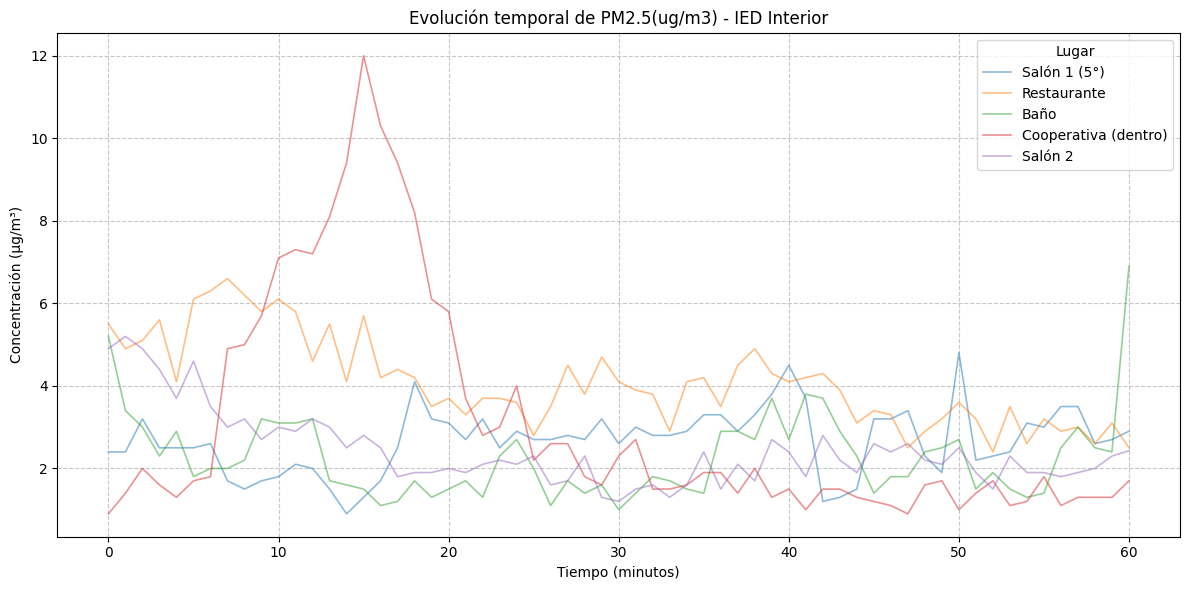

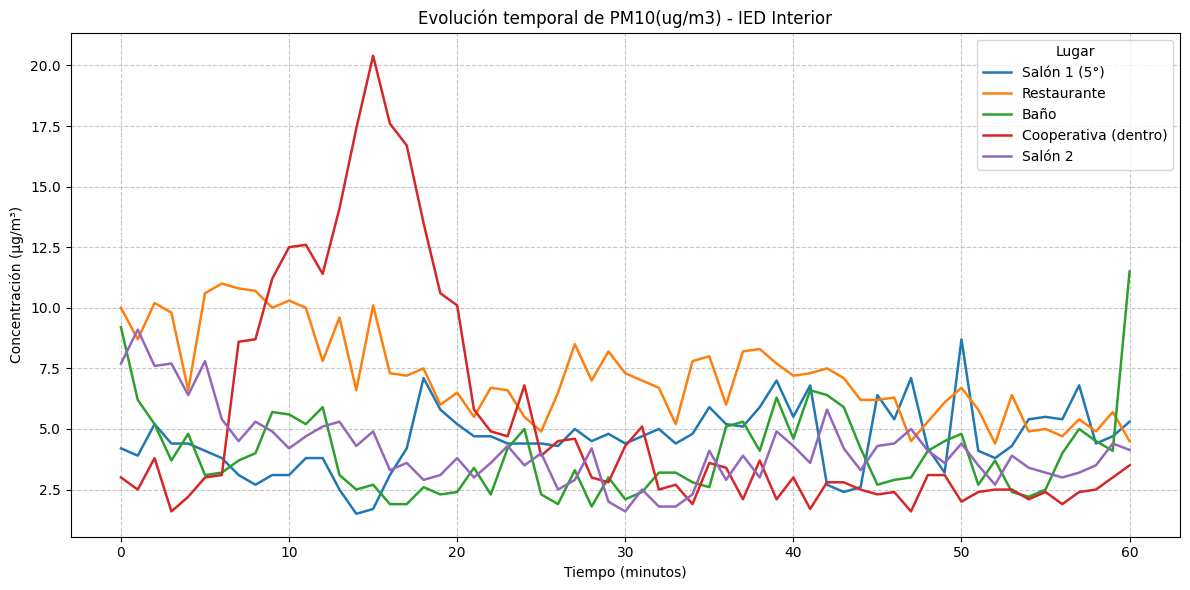

Could not determine dtype for column 1, falling back to string



📈 Analizando serie temporal: Santa Juanita Interior


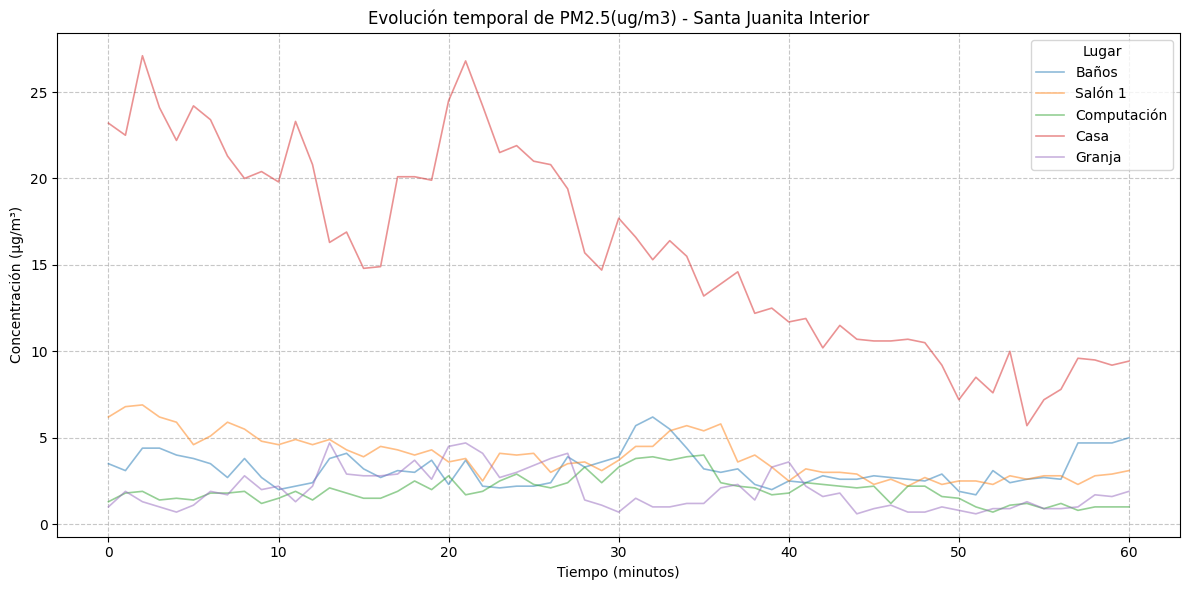

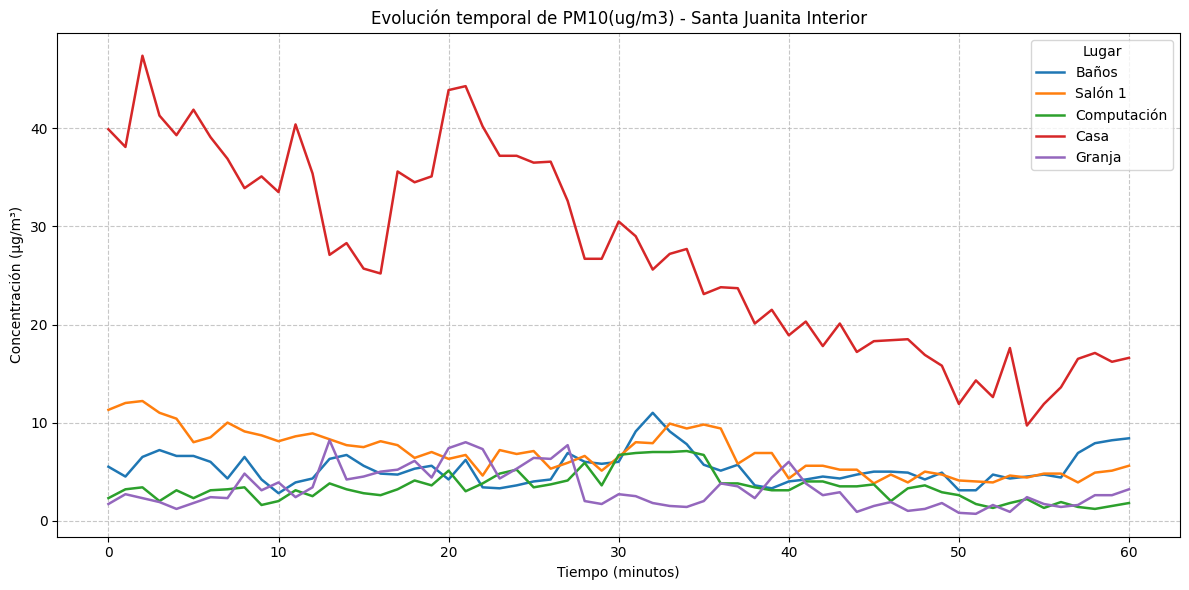

In [9]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# =================
# CONFIGURACIÓN
# =================
file_path = "Datos Unificados.ods"
sheets = ["IED Interior", "Santa Juanita Interior"]
variables = ["PM2.5(ug/m3)", "PM10(ug/m3)"]

# Paleta base: tab10 (10 colores distintos para los lugares)
colormap = plt.cm.get_cmap("tab10")


# =================
# FUNCIÓN DE ANÁLISIS TEMPORAL
# =================
def analizar_tiempo(sheet_name):
    print(f"\n📈 Analizando serie temporal: {sheet_name}")

    # 1. Cargar datos
    df = pl.read_excel(file_path, sheet_name=sheet_name)

    if "Lugar" not in df.columns:
        print(f"⚠️ No existe columna 'Lugar' en {sheet_name}")
        return

    # 2. Obtener lugares únicos
    lugares = df["Lugar"].unique().to_list()

    # 3. Graficar PM2.5 (colores claros) y PM10 (colores oscuros)
    for var in variables:
        plt.figure(figsize=(12, 6))

        for i, lugar in enumerate(lugares):
            subset = df.filter(df["Lugar"] == lugar).with_row_index("Tiempo")

            # Asignar color base
            base_color = colormap(i % 10)

            # Ajustar brillo según contaminante
            if var == "PM2.5(ug/m3)":
                color = (*base_color[:3], 0.5)  # versión más clara (más transparente)
            else:  # PM10
                color = base_color  # versión más oscura (pleno color)

            plt.plot(
                subset["Tiempo"].to_list(),
                subset[var].to_list(),
                label=lugar,
                color=color,
                linewidth=1.8 if var == "PM10(ug/m3)" else 1.2,  # PM10 más grueso
            )

        # Personalizar gráfico
        plt.title(f"Evolución temporal de {var} - {sheet_name}")
        plt.xlabel("Tiempo (minutos)")
        plt.ylabel("Concentración (µg/m³)")
        plt.legend(title="Lugar")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()


# =================
# EJECUCIÓN
# =================
for sheet in sheets:
    analizar_tiempo(sheet)


In [13]:
# =================
# ANÁLISIS PM2.5 Y TRÁFICO CON SOMBREADO DE RANGO
# =================

import pandas as pd
import matplotlib.pyplot as plt

# =================
# CARGA Y PREPARACIÓN DE DATOS
# =================
file_path = "pm25_trafico.xlsx"
df = pd.read_excel(file_path)

# Transponemos la tabla para organizar correctamente los valores
df = df.set_index(df.columns[0]).T.reset_index().rename(columns={"index": "Ubicación"})

# Convertimos columnas a numéricas
df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce")
df["Max"] = pd.to_numeric(df["Max"], errors="coerce")
df["Min"] = pd.to_numeric(df["Min"], errors="coerce")
df["Vehículos"] = pd.to_numeric(df["TOTAL [Vehi/h]"], errors="coerce")

# =================
# CLASIFICACIÓN DE FRECUENCIA
# =================
def clasificar_frecuencia(valor):
    if valor <= 50:
        return "Muy bajo"
    elif valor <= 150:
        return "Bajo"
    elif valor <= 350:
        return "Moderado"
    else:
        return "Alto"

df["Frecuencia calculada"] = df["Vehículos"].apply(clasificar_frecuencia)

# =================
# GRÁFICA COMBINADA
# =================
colores = {
    "Muy bajo": "#a6cee3",
    "Bajo": "#1f78b4",
    "Moderado": "#33a02c",
    "Alto": "#e31a1c"
}

plt.figure(figsize=(10, 6))

# Barras de vehículos (color según frecuencia)
bars = plt.bar(
    df["Ubicación"],
    df["Vehículos"],
    color=[colores[f] for f in df["Frecuencia calculada"]],
    edgecolor="black",
    alpha=0.8,
    label="Vehículos (frecuencia)"
)

# Línea de PM2.5 promedio
plt.plot(
    df["Ubicación"],
    df["PM2.5"],
    color="black",
    marker="o",
    linewidth=2,
    label="PM2.5 promedio (µg/m³)"
)

# Región sombreada entre mínimo y máximo
plt.fill_between(
    df["Ubicación"],
    df["Min"],
    df["Max"],
    color="gray",
    alpha=0.2,
    label="Rango PM2.5 (mín–máx)"
)

# Etiquetas sobre los puntos de PM2.5
for i, v in enumerate(df["PM2.5"]):
    plt.text(i, v + 5, f"{v:.1f}", ha="center", fontsize=9, color="black")

# =================
# PERSONALIZACIÓN
# =================
plt.title("Relación entre tráfico vehicular y PM2.5 por calle", fontsize=13, weight="bold")
plt.ylabel("Vehículos / Concentración de PM2.5 (µg/m³)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colores[k], edgecolor='black', label=k) for k in colores]
plt.legend(handles=legend_elements + [plt.Line2D([], [], color='black', marker='o', label='PM2.5 promedio'),
                                      plt.Rectangle((0,0),1,1, color='gray', alpha=0.2, label='Rango PM2.5 (mín–máx)')],
           title="Leyenda")

plt.tight_layout()
plt.show()

# =================
# REVISIÓN DE DATOS
# =================
print(df[["Ubicación", "Vehículos", "PM2.5", "Min", "Max", "Frecuencia calculada"]])


KeyError: 'Max'

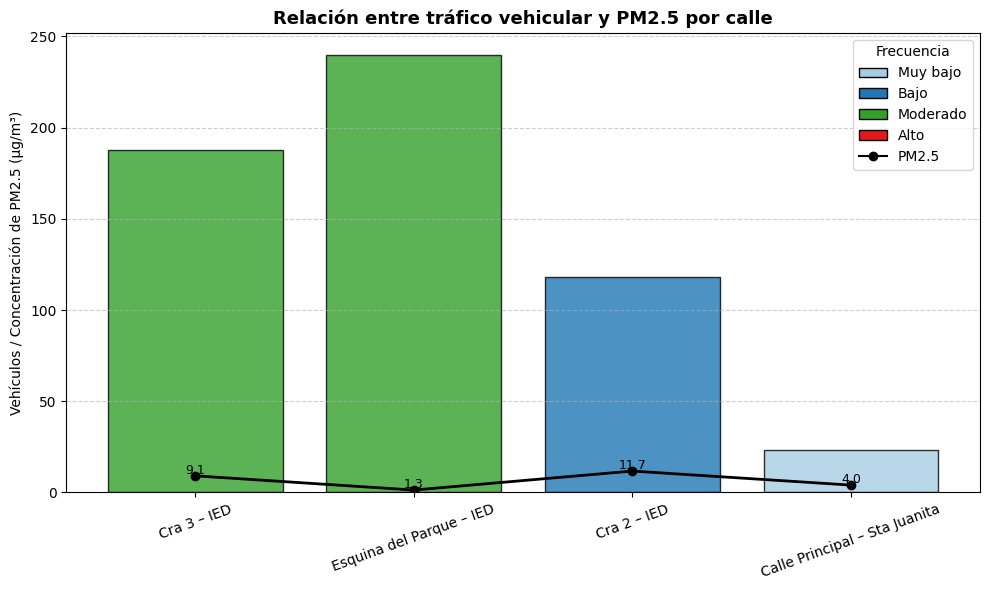

Vehículos                      Ubicación  Vehículos      PM2.5  \
0                            Cra 3 – IED        188   9.057024   
1               Esquina del Parque – IED        240   1.258550   
2                            Cra 2 – IED        118  11.678177   
3          Calle Principal – Sta Juanita         23   3.969697   

Vehículos Frecuencia calculada  
0                     Moderado  
1                     Moderado  
2                         Bajo  
3                     Muy bajo  


In [2]:
# =================
# ANÁLISIS PM2.5 Y TRÁFICO
# =================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =================
# CARGA DE DATOS
# =================
file_path = "pm25_trafico.xlsx"

# Se lee la hoja por defecto
df = pd.read_excel(file_path)

# Transponemos para organizar los datos correctamente
df = df.set_index(df.columns[0]).T.reset_index().rename(columns={"index": "Ubicación"})

# Convertimos los valores a numéricos cuando aplica
df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce")
df["Vehículos"] = pd.to_numeric(df["TOTAL [Vehi/h]"], errors="coerce")

# =================
# CLASIFICACIÓN DE FRECUENCIA
# =================
def clasificar_frecuencia(valor):
    if valor <= 50:
        return "Muy bajo"
    elif valor <= 150:
        return "Bajo"
    elif valor <= 350:
        return "Moderado"
    else:
        return "Alto"

df["Frecuencia calculada"] = df["Vehículos"].apply(clasificar_frecuencia)

# =================
# GRÁFICA COMBINADA
# =================

# Colores por categoría
colores = {
    "Muy bajo": "#a6cee3",
    "Bajo": "#1f78b4",
    "Moderado": "#33a02c",
    "Alto": "#e31a1c"
}

plt.figure(figsize=(10, 6))

# Barras principales (vehículos)
bars = plt.bar(
    df["Ubicación"],
    df["Vehículos"],
    color=[colores[f] for f in df["Frecuencia calculada"]],
    edgecolor="black",
    alpha=0.8,
    label="Vehículos (frecuencia)"
)

# Línea secundaria (PM2.5)
plt.plot(
    df["Ubicación"],
    df["PM2.5"],
    color="black",
    marker="o",
    linewidth=2,
    label="PM2.5 promedio (µg/m³)"
)

# Etiquetas de PM2.5 sobre la línea
for i, v in enumerate(df["PM2.5"]):
    plt.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9, color="black")

# =================
# PERSONALIZACIÓN
# =================
plt.title("Relación entre tráfico vehicular y PM2.5 por calle", fontsize=13, weight="bold")
plt.ylabel("Vehículos / Concentración de PM2.5 (µg/m³)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Leyenda por categoría
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colores[k], edgecolor='black', label=k) for k in colores]
plt.legend(handles=legend_elements + [plt.Line2D([], [], color='black', marker='o', label='PM2.5')], title="Frecuencia")

plt.tight_layout()
plt.show()

# =================
# REVISIÓN DE DATOS
# =================
print(df[["Ubicación", "Vehículos", "PM2.5", "Frecuencia calculada"]])


/tmp/ipykernel_102462/2003373691.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("tab10")
Could not determine dtype for column 1, falling back to string



📊 Analizando PM2.5: IED Exterior


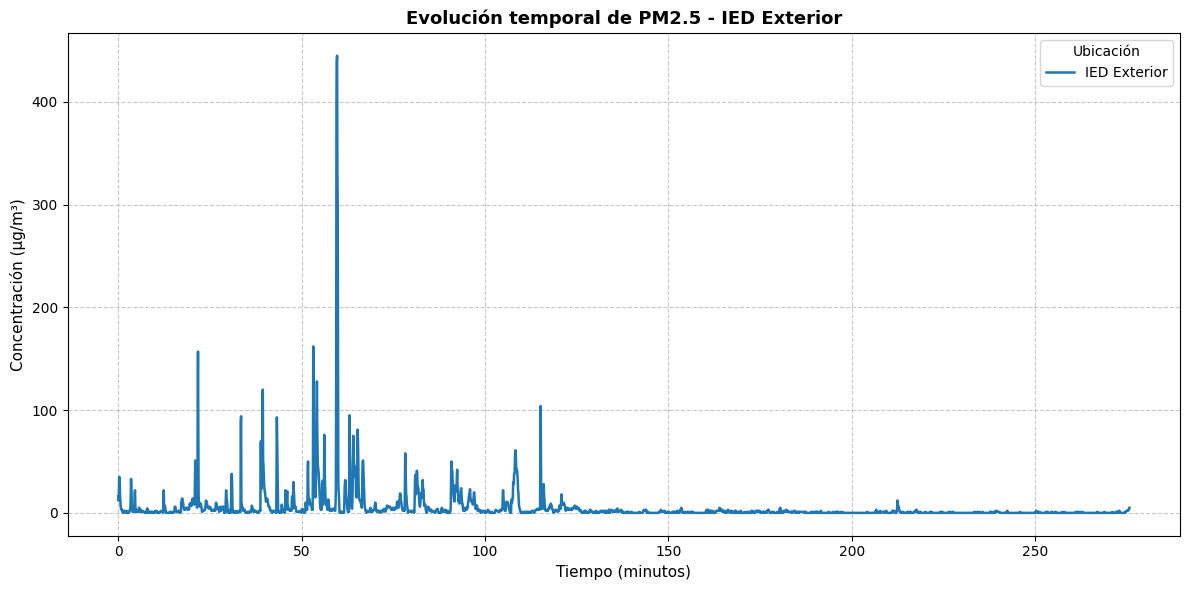

Could not determine dtype for column 1, falling back to string



📊 Analizando PM2.5: Santa Juanita Exterior


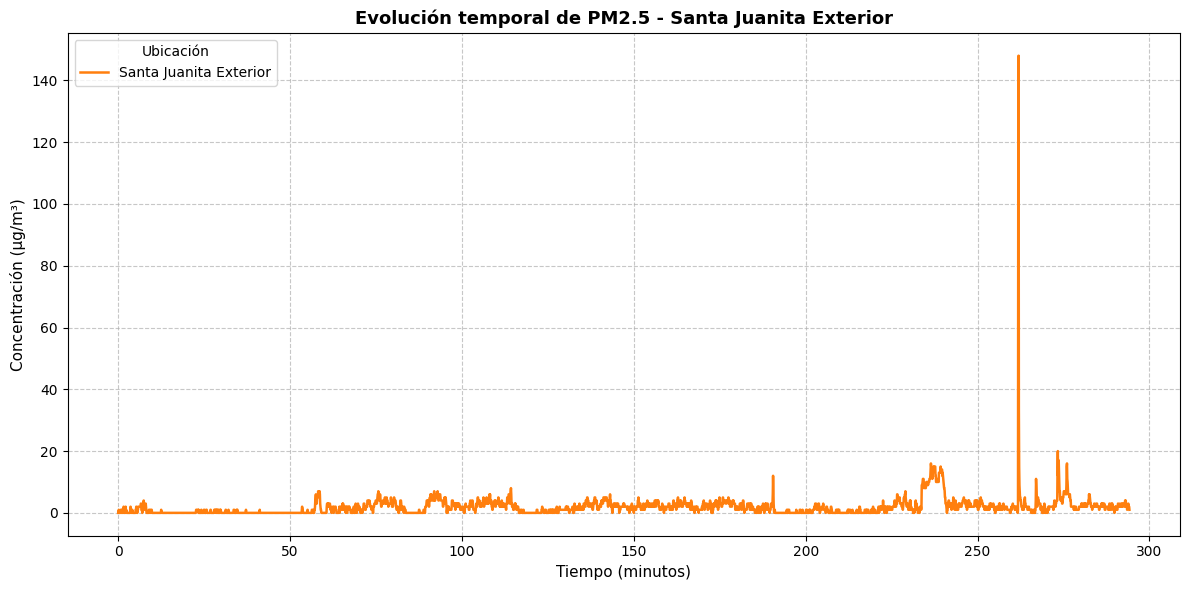

In [ ]:
# =================
# ANÁLISIS PM2.5 - EXTERIOR
# =================

import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# =================
# CONFIGURACIÓN
# =================
file_path = "Datos Unificados1.ods"
sheets = ["IED Exterior", "Santa Juanita Exterior"]
variable = "PM2.5(ug/m3)"

# Paleta de colores
colormap = plt.cm.get_cmap("tab10")

# =================
# FUNCIÓN DE ANÁLISIS TEMPORAL
# =================
def analizar_pm25(sheet_name):
    print(f"\n Analizando PM2.5: {sheet_name}")

    # 1. Cargar datos
    df = pl.read_excel(file_path, sheet_name=sheet_name)

    # 2. Validar columnas esperadas
    if variable not in df.columns:
        print(f"⚠️ La hoja '{sheet_name}' no tiene la columna {variable}")
        return

    # 3. Crear índice temporal (cada 5 segundos → 12 datos/minuto)
    df = df.with_row_index("Tiempo")
    df = df.with_columns((df["Tiempo"] / 12).alias("Minutos"))  # Conversión

    # 4. Graficar PM2.5
    plt.figure(figsize=(12, 6))
    plt.plot(
        df["Minutos"],
        df[variable],
        label=sheet_name,
        color=colormap(0 if "IED" in sheet_name else 1),
        linewidth=1.8
    )

    # 5. Personalizar gráfico
    plt.title(f"Evolución temporal de PM2.5 - {sheet_name}", fontsize=13, weight="bold")
    plt.xlabel("Tiempo (minutos)", fontsize=11)
    plt.ylabel("Concentración (µg/m³)", fontsize=11)
    plt.legend(title="Ubicación")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


# =================
# EJECUCIÓN
# =================
for sheet in sheets:
    analizar_pm25(sheet)


## ANOVA

In [11]:
import polars as pl
from pyexcel_ods3 import get_data
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --- 1️⃣ Leer tu hoja de LibreOffice (.ods) ---
archivo = "Datos Unificados1.ods"
data = get_data(archivo)

# Seleccionar la hoja que contiene tus datos
hoja = data["Promedios y desviacion"]

# La primera fila son los encabezados
columnas = hoja[0]
filas = hoja[1:]

# Crear DataFrame de Polars
df = pl.DataFrame(filas, schema=columnas)

# --- 2️⃣ Limpiar nombres de columnas ---
df = df.rename({col: col.strip().replace(" ", "_").replace(".", "_") for col in df.columns})

# --- 3️⃣ Convertir columnas numéricas ---
for col in df.columns:
    if df[col].dtype == pl.Utf8:
        try:
            df = df.with_columns(pl.col(col).cast(pl.Float64))
        except:
            pass  # ignora las que no se pueden convertir

# --- 4️⃣ ANOVA para PM2_5 (interior vs exterior × colegio) ---
# Solo columnas relevantes
df_pm25 = df.select(["Colegio", "Espacio", "Punto_de_Monitor", "PM2_5(ug/m3)_MEAN"]).drop_nulls()

# Convertir a pandas para statsmodels (obligatorio para fórmula)
df_pm25_pd = df_pm25.to_pandas()

# Modelo ANOVA de dos factores
modelo = ols("`PM2_5(ug/m3)_MEAN` ~ C(Espacio) + C(Colegio) + C(Espacio):C(Colegio)", data=df_pm25_pd).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

print("\n📊 ANOVA 1: PM2.5 (Interior vs Exterior × Colegio)")
print(anova_tabla)

# --- 5️⃣ ANOVA solo para interiores (varios contaminantes) ---
df_int = df.filter(pl.col("Espacio") == "Interior")
df_int_pd = df_int.to_pandas()

contaminantes = [
    "PM2_5(ug/m3)_MEAN",
    "PM10(ug/m3)_MEAN",
    "HCHO(mg/m3)_MEAN",
    "TVOC(mg/m3)_MEAN"
]

for var in contaminantes:
    if var in df_int_pd.columns:
        modelo = ols(f"`{var}` ~ C(Colegio) + C(Punto_de_Monitor)", data=df_int_pd).fit()
        anova_tabla = sm.stats.anova_lm(modelo, typ=2)
        print(f"\n📊 ANOVA para {var} (solo interiores)")
        print(anova_tabla)


ModuleNotFoundError: No module named 'pyexcel_ods3'

In [ ]:
import polars as pl

file_path = "Datos Unificados.ods"
df = pl.read_excel(file_path, sheet_name="Santa Juanita Interior")

# 1. Limpiar texto en columna Lugar
df = df.with_columns(
    pl.col("Lugar")
    .str.strip_chars()         # quita espacios antes y después
    .str.replace_all(r"\s+", " ")  # unifica espacios múltiples
    .alias("Lugar")
)

# 2. Revisar valores únicos de nuevo
print("Lugares únicos:", df["Lugar"].unique().to_list())

# 3. Contar registros por lugar
print(df.group_by("Lugar").count())

# 4. Revisar específicamente si está "Salón 1"
print(df.filter(pl.col("Lugar") == "Salón 1"))


Could not determine dtype for column 1, falling back to string


Lugares únicos: ['Granja', 'Baños', 'Computación', 'Casa', 'Salón 1']
shape: (5, 2)
┌─────────────┬───────┐
│ Lugar       ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ Computación ┆ 61    │
│ Casa        ┆ 61    │
│ Baños       ┆ 61    │
│ Salón 1     ┆ 61    │
│ Granja      ┆ 61    │
└─────────────┴───────┘
shape: (61, 12)
┌─────────┬─────────────┬─────────────┬─────────────┬───┬────────────┬──────┬───────────┬──────────┐
│ Lugar   ┆ Coordenadas ┆ DATE        ┆ PM2.5(ug/m3 ┆ … ┆ TVOC(mg/m3 ┆ TEMP ┆ HUMI(%RH) ┆ TEMPUNIT │
│ ---     ┆ ---         ┆ ---         ┆ )           ┆   ┆ )          ┆ ---  ┆ ---       ┆ ---      │
│ str     ┆ str         ┆ str         ┆ ---         ┆   ┆ ---        ┆ f64  ┆ f64       ┆ str      │
│         ┆             ┆             ┆ f64         ┆   ┆ f64        ┆      ┆           ┆          │
╞═════════╪═════════════╪═════════════╪═════════════╪═══╪════════════╪══════╪═══════════╪══════════╡
│ Salón 1 ┆ null        ┆ 2025

/tmp/ipykernel_7949/2462359031.py:18: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  print(df.group_by("Lugar").count())


Could not determine dtype for column 1, falling back to string



📊 Analizando hoja: IED Interior
shape: (9, 3)
┌────────────┬──────────────┬─────────────┐
│ statistic  ┆ PM2.5(ug/m3) ┆ PM10(ug/m3) │
│ ---        ┆ ---          ┆ ---         │
│ str        ┆ f64          ┆ f64         │
╞════════════╪══════════════╪═════════════╡
│ count      ┆ 305.0        ┆ 305.0       │
│ null_count ┆ 0.0          ┆ 0.0         │
│ mean       ┆ 2.906322     ┆ 5.06012     │
│ std        ┆ 1.62046      ┆ 2.82552     │
│ min        ┆ 0.9          ┆ 1.5         │
│ 25%        ┆ 1.8          ┆ 3.1         │
│ 50%        ┆ 2.6          ┆ 4.4         │
│ 75%        ┆ 3.5          ┆ 6.2         │
│ max        ┆ 12.0         ┆ 20.4        │
└────────────┴──────────────┴─────────────┘


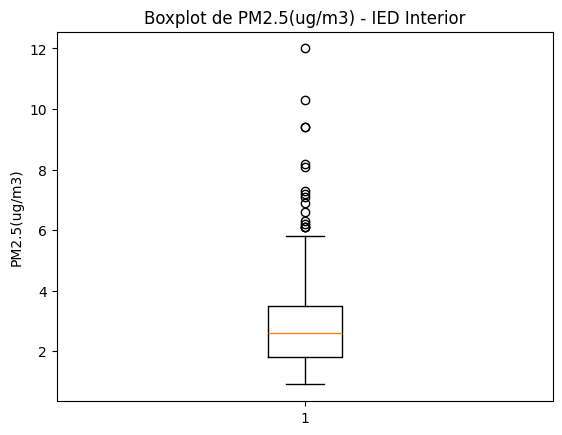

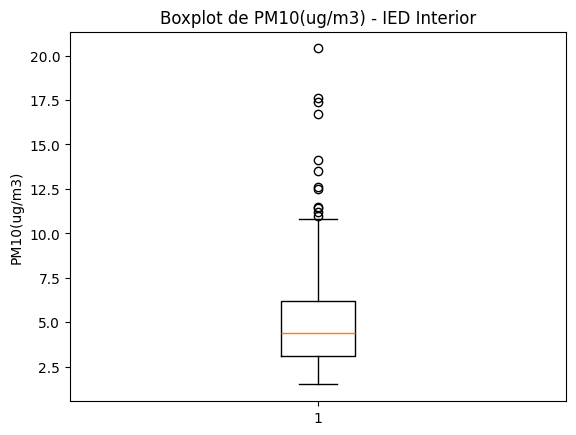

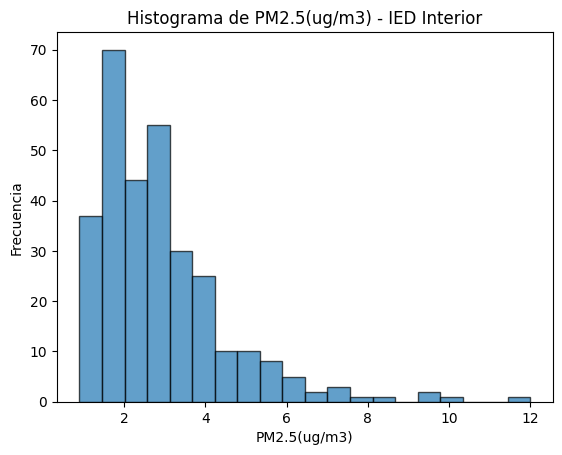

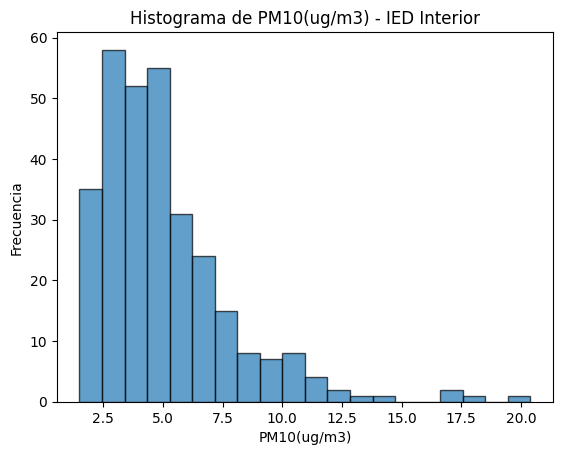

Could not determine dtype for column 1, falling back to string


⚠️ No se encontró columna de tiempo, no se generó serie temporal.

📊 Analizando hoja: Santa Juanita Interior
shape: (9, 3)
┌────────────┬──────────────┬─────────────┐
│ statistic  ┆ PM2.5(ug/m3) ┆ PM10(ug/m3) │
│ ---        ┆ ---          ┆ ---         │
│ str        ┆ f64          ┆ f64         │
╞════════════╪══════════════╪═════════════╡
│ count      ┆ 305.0        ┆ 305.0       │
│ null_count ┆ 0.0          ┆ 0.0         │
│ mean       ┆ 5.403716     ┆ 9.250164    │
│ std        ┆ 6.00133      ┆ 10.325101   │
│ min        ┆ 0.6          ┆ 0.7         │
│ 25%        ┆ 2.0          ┆ 3.4         │
│ 50%        ┆ 3.0          ┆ 5.1         │
│ 75%        ┆ 5.0          ┆ 8.7         │
│ max        ┆ 27.1         ┆ 47.4        │
└────────────┴──────────────┴─────────────┘


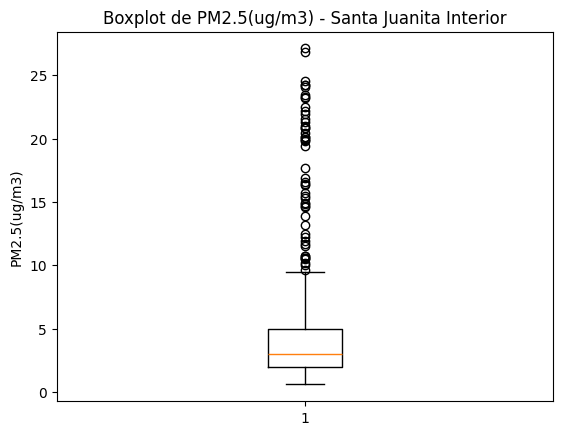

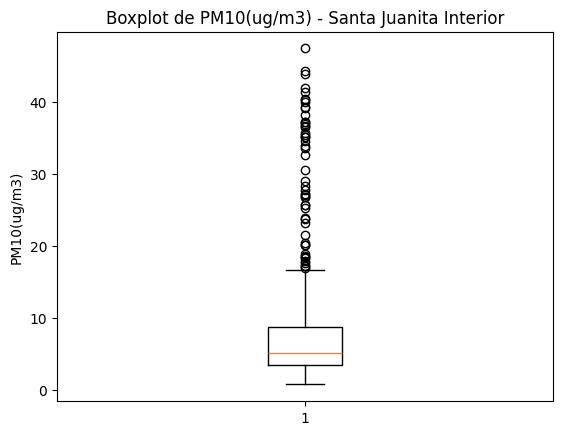

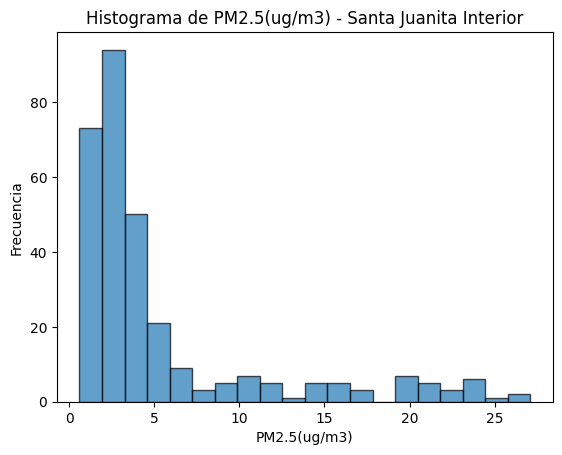

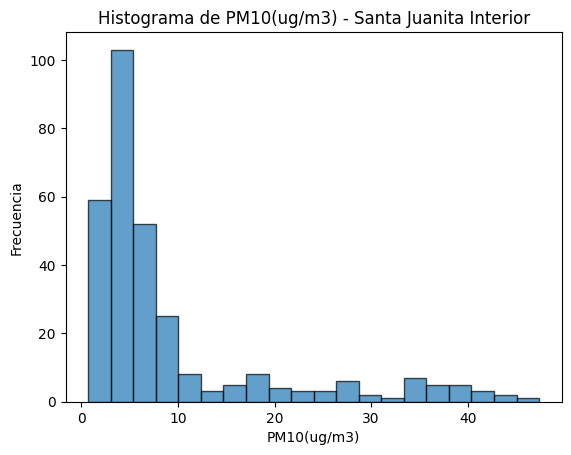

⚠️ No se encontró columna de tiempo, no se generó serie temporal.


In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# ================
# CONFIGURACIÓN
# ================
file_path = "Datos Unificados.ods"

# Nombres de las hojas en tu archivo (ajusta según corresponda)
sheets = ["IED Interior", "Santa Juanita Interior"]

# Variables que vamos a analizar
variables = ["PM2.5(ug/m3)", "PM10(ug/m3)"]


# ================
# FUNCIÓN DE ANÁLISIS
# ================
def analisis_exploratorio(sheet_name):
    print(f"\n📊 Analizando hoja: {sheet_name}")

    # 1. Cargar datos
    df = pl.read_excel(file_path, sheet_name=sheet_name)

    # 2. Verificar que estén las columnas necesarias
    for col in variables:
        if col not in df.columns:
            print(f"⚠️ La variable {col} no está en {sheet_name}")
            return

    # 3. Estadísticas descriptivas
    print(df.select(variables).describe())

    # 4. Boxplots
    for var in variables:
        plt.boxplot(df[var].drop_nulls().to_list())
        plt.title(f"Boxplot de {var} - {sheet_name}")
        plt.ylabel(var)
        plt.show()

    # 5. Histogramas
    for var in variables:
        plt.hist(df[var].drop_nulls().to_list(), bins=20, alpha=0.7, edgecolor="black")
        plt.title(f"Histograma de {var} - {sheet_name}")
        plt.xlabel(var)
        plt.ylabel("Frecuencia")
        plt.show()

    # 6. Serie de tiempo (asumiendo que tienes una columna de tiempo)
    if "Tiempo" in df.columns:
        for var in variables:
            plt.plot(df["Date"].to_list(), df[var].to_list(), label=var)
        plt.title(f"Serie de tiempo - {sheet_name}")
        plt.xlabel("Tiempo")
        plt.ylabel("Concentración (µg/m³)")
        plt.legend()
        plt.show()
    else:
        print("⚠️ No se encontró columna de tiempo, no se generó serie temporal.")


# ================
# EJECUCIÓN
# ================
for sheet in sheets:
    analisis_exploratorio(sheet)
